In [ ]:
#Core data manipulation
import pandas as pd
import numpy as np
#Visualisation
import matplotlib.pyplot as plt
#Machine Learning processing 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [ ]:
#U.S Government dataset
file_path = "Raw data.csv"  
df = pd.read_csv(file_path)

#shows basic structure of the dataset 
print("Raw shape:", df.shape)
df.head()


Raw shape: (81248, 15)


,Record Date,Electronic Category Description,Channel Type Description,Tax Category Description,Net Collections Amount,Electronic Category ID,Channel Type ID,Tax Category ID,Source Line Number,Fiscal Year,Fiscal Quarter Number,Calendar Year,Calendar Quarter Number,Calendar Month Number,Calendar Day Number
0,2023-12-27,Non-Electronic,Mail,Non-Tax,726.95,4,2,1,1,2024,1,2023,4,12,27
1,2023-12-27,Electronic Settlement,Over-the-Counter (OTC),Non-Tax,243104.79,3,1,1,2,2024,1,2023,4,12,27
2,2023-12-27,Non-Electronic,Over-the-Counter (OTC),Non-Tax,9395109.54,4,1,1,3,2024,1,2023,4,12,27
3,2023-12-27,Fully Electronic - FS,Over-the-Counter (OTC),IRS Non-Tax,48241.05,2,1,2,4,2024,1,2023,4,12,27
4,2023-12-27,Fully Electronic - All,Bank,IRS Tax,2905.82,1,5,3,5,2024,1,2023,4,12,27


In [26]:
print(df.columns)
print(df.dtypes)


Index(['Record Date', 'Electronic Category Description',
       'Channel Type Description', 'Tax Category Description',
       'Net Collections Amount', 'Electronic Category ID', 'Channel Type ID',
       'Tax Category ID', 'Source Line Number', 'Fiscal Year',
       'Fiscal Quarter Number', 'Calendar Year', 'Calendar Quarter Number',
       'Calendar Month Number', 'Calendar Day Number'],
      dtype='object')
Record Date                         object
Electronic Category Description     object
Channel Type Description            object
Tax Category Description            object
Net Collections Amount             float64
Electronic Category ID               int64
Channel Type ID                      int64
Tax Category ID                      int64
Source Line Number                   int64
Fiscal Year                          int64
Fiscal Quarter Number                int64
Calendar Year                        int64
Calendar Quarter Number              int64
Calendar Month Number     

In [ ]:

required_cols = [
    "Record Date",
    "Electronic Category Description",
    "Channel Type Description",
    "Tax Category Description",
    "Net Collections Amount",
    "Fiscal Year",                 
    "Fiscal Quarter Number"        # shows column index 
]

keep_cols = [c for c in required_cols if c in df.columns]
df = df[keep_cols].copy()

print("After keep cols shape:", df.shape)
df.head()


After keep cols shape: (81248, 7)


,Record Date,Electronic Category Description,Channel Type Description,Tax Category Description,Net Collections Amount,Fiscal Year,Fiscal Quarter Number
0,2023-12-27,Non-Electronic,Mail,Non-Tax,726.95,2024,1
1,2023-12-27,Electronic Settlement,Over-the-Counter (OTC),Non-Tax,243104.79,2024,1
2,2023-12-27,Non-Electronic,Over-the-Counter (OTC),Non-Tax,9395109.54,2024,1
3,2023-12-27,Fully Electronic - FS,Over-the-Counter (OTC),IRS Non-Tax,48241.05,2024,1
4,2023-12-27,Fully Electronic - All,Bank,IRS Tax,2905.82,2024,1


In [ ]:
#check data type 
df["Record Date"] = pd.to_datetime(df["Record Date"], errors="coerce")


df["Net Collections Amount"] = pd.to_numeric(df["Net Collections Amount"], errors="coerce")

# Drop rows where date OR target is missing
df = df.dropna(subset=["Record Date", "Net Collections Amount"])

print("After date/target cleaning shape:", df.shape)
df.head()


After date/target cleaning shape: (81248, 7)


,Record Date,Electronic Category Description,Channel Type Description,Tax Category Description,Net Collections Amount,Fiscal Year,Fiscal Quarter Number
0,2023-12-27,Non-Electronic,Mail,Non-Tax,726.95,2024,1
1,2023-12-27,Electronic Settlement,Over-the-Counter (OTC),Non-Tax,243104.79,2024,1
2,2023-12-27,Non-Electronic,Over-the-Counter (OTC),Non-Tax,9395109.54,2024,1
3,2023-12-27,Fully Electronic - FS,Over-the-Counter (OTC),IRS Non-Tax,48241.05,2024,1
4,2023-12-27,Fully Electronic - All,Bank,IRS Tax,2905.82,2024,1


In [ ]:
#Extract year and month from date 
df["Year"] = df["Record Date"].dt.year.astype(int)
df["Month"] = df["Record Date"].dt.month.astype(int)

group_cols = [
    "Year",
    "Month",
    "Electronic Category Description",
    "Channel Type Description",
    "Tax Category Description"
]

df_monthly = (
    df.groupby(group_cols, as_index=False)["Net Collections Amount"]
      .sum()
)

print("Monthly shape:", df_monthly.shape)
df_monthly.head()



Monthly shape: (4282, 6)


,Year,Month,Electronic Category Description,Channel Type Description,Tax Category Description,Net Collections Amount
0,2004,10,Fully Electronic - All,Bank,IRS Non-Tax,7.833900e+04
1,2004,10,Fully Electronic - All,Bank,IRS Tax,2.533201e+10
2,2004,10,Fully Electronic - All,Bank,Non-Tax,2.107339e+10
3,2004,10,Fully Electronic - All,Internet,IRS Tax,9.580596e+10
4,2004,10,Fully Electronic - All,Internet,Non-Tax,2.714651e+08


In [ ]:
df_monthly["Month_sin"] = np.sin(2 * np.pi * df_monthly["Month"] / 12)
df_monthly["Month_cos"] = np.cos(2 * np.pi * df_monthly["Month"] / 12) # Encode month as a sin and cos in seasonality
# avoid discontinuity between December and January
df_monthly.head()


,Year,Month,Electronic Category Description,Channel Type Description,Tax Category Description,Net Collections Amount,Month_sin,Month_cos
0,2004,10,Fully Electronic - All,Bank,IRS Non-Tax,7.833900e+04,-0.866025,0.5
1,2004,10,Fully Electronic - All,Bank,IRS Tax,2.533201e+10,-0.866025,0.5
2,2004,10,Fully Electronic - All,Bank,Non-Tax,2.107339e+10,-0.866025,0.5
3,2004,10,Fully Electronic - All,Internet,IRS Tax,9.580596e+10,-0.866025,0.5
4,2004,10,Fully Electronic - All,Internet,Non-Tax,2.714651e+08,-0.866025,0.5


In [ ]:
#Aggregate monthly data for forecating consistency 
df_monthly["YearMonth"] = pd.to_datetime(
    df_monthly["Year"].astype(str) + "-" + df_monthly["Month"].astype(str) + "-01"
)

df_monthly = df_monthly.sort_values("YearMonth").reset_index(drop=True)

df_monthly[["Year", "Month", "YearMonth"]].head()


,Year,Month,YearMonth
0,2004,10,2004-10-01
1,2004,10,2004-10-01
2,2004,10,2004-10-01
3,2004,10,2004-10-01
4,2004,10,2004-10-01


In [ ]:
target = "Net Collections Amount"

# Drop any remaining NaN in target 
df_monthly = df_monthly.dropna(subset=[target]).copy()

X = df_monthly.drop(columns=[target])
y = df_monthly[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaN in y?:", y.isnull().sum())


X shape: (4282, 8)
y shape: (4282,)
Any NaN in y?: 0


In [ ]:
#split data into train and test
#80/20 split to aviod overfitting and look-ahead bias 
split_point = int(len(df_monthly) * 0.8)

X_train = X.iloc[:split_point].copy()
X_test  = X.iloc[split_point:].copy()

y_train = y.iloc[:split_point].copy()
y_test  = y.iloc[split_point:].copy()

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (3425, 8) (3425,)
Test : (857, 8) (857,)


In [ ]:
# Define categorical and numeric features 
categorical_features = [
    "Electronic Category Description",
    "Channel Type Description",
    "Tax Category Description"
]

numeric_features = [
    "Year",
    "Month_sin",
    "Month_cos"
]

# Using one-hot encoding to categorical feautures 
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ],
    remainder="drop"
)

print("Preprocess ready ✅")


Preprocess ready ✅


In [ ]:
#Create linear regression pipeline 
lr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])
#Train linear regression model
# Generate predictions 
lr_model.fit(X_train, y_train)
pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_lr  = mean_absolute_error(y_test, pred_lr)
r2_lr   = r2_score(y_test, pred_lr)

print("=== Linear Regression ===")
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("R2  :", r2_lr)


=== Linear Regression ===
RMSE: 66148434213.073784
MAE : 32596405371.553486
R2  : 0.295901730302349


In [ ]:
#Create Random forest pipeline 
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])
#Train Random Forest model
#Generate predictions 
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf  = mean_absolute_error(y_test, pred_rf)
r2_rf   = r2_score(y_test, pred_rf)

print("=== Random Forest ===")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)
print("R2  :", r2_rf)


=== Random Forest ===
RMSE: 26201978366.279884
MAE : 6913547905.300553
R2  : 0.8895254331569538


In [ ]:
#Evaluate both models performance 
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "MAE": [mae_lr, mae_rf],
    "R2": [r2_lr, r2_rf]
}).sort_values("RMSE")

results


,Model,RMSE,MAE,R2
1,Random Forest,2.620198e+10,6.913548e+09,0.889525
0,Linear Regression,6.614843e+10,3.259641e+10,0.295902


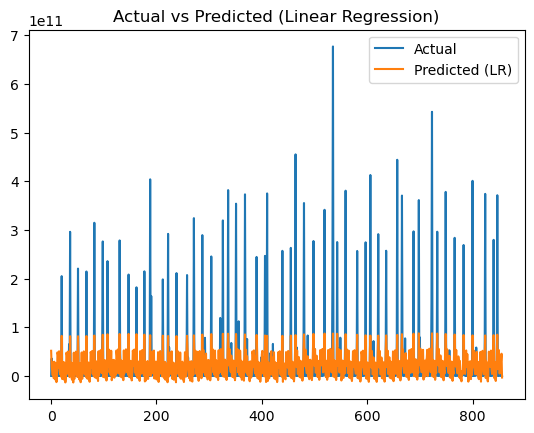

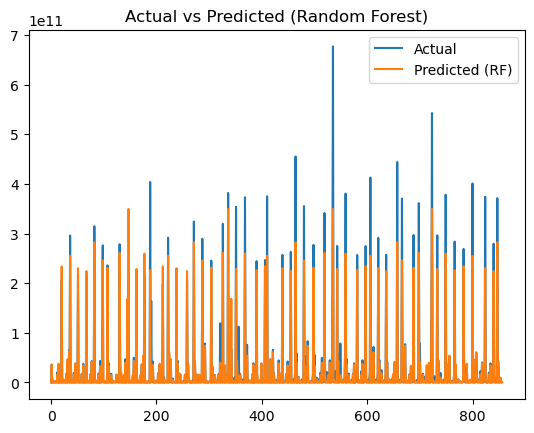

In [ ]:
#Build the actual vs predicted values for both models 
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(pred_lr, label="Predicted (LR)")
plt.title("Actual vs Predicted (Linear Regression)")
plt.legend()
plt.show()

plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(pred_rf, label="Predicted (RF)")
plt.title("Actual vs Predicted (Random Forest)")
plt.legend()
plt.show()


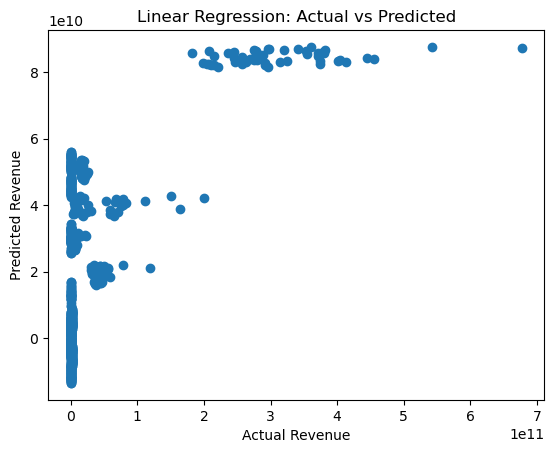

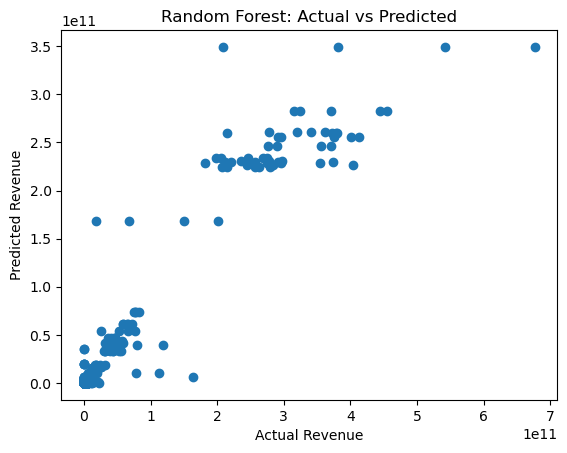

In [ ]:
#Plot the actual vs predicted values for both models 
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, pred_lr)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

plt.figure()
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Random Forest: Actual vs Predicted")
plt.show()


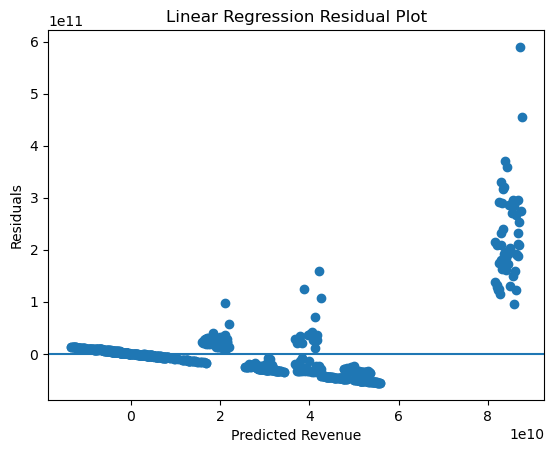

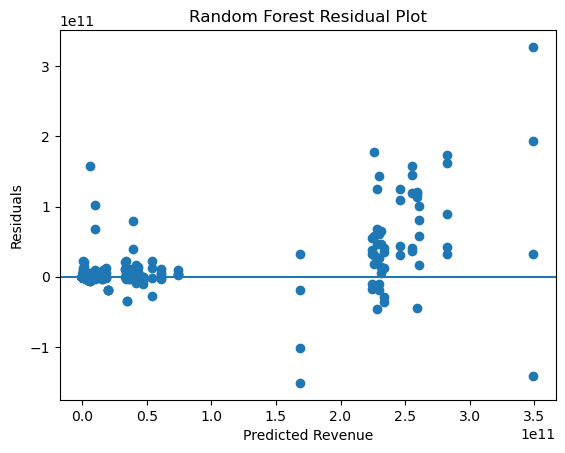

In [ ]:
#Build a Residual Plot for both models 
residual_lr = y_test - pred_lr
residual_rf = y_test - pred_rf

plt.figure()
plt.scatter(pred_lr, residual_lr)
plt.axhline(y=0)
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.show()

plt.figure()
plt.scatter(pred_rf, residual_rf)
plt.axhline(y=0)
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")
plt.show()


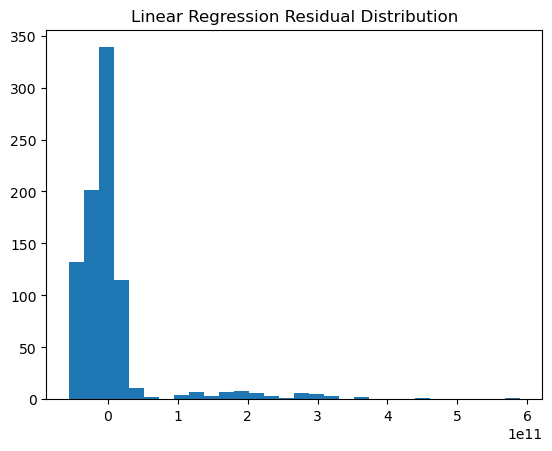

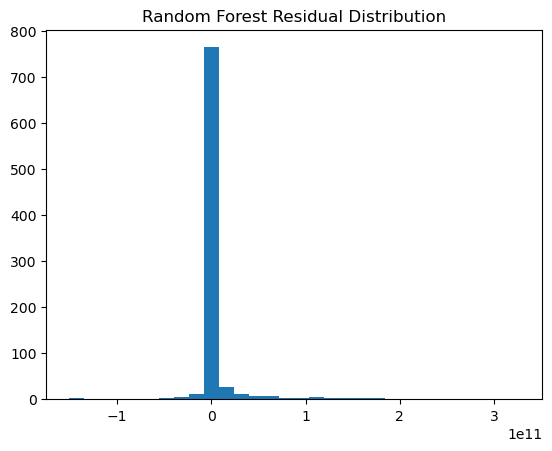

In [ ]:
#Build a Residual Analysis
plt.figure()
plt.hist(residual_lr, bins=30)
plt.title("Linear Regression Residual Distribution")
plt.show()

plt.figure()
plt.hist(residual_rf, bins=30)
plt.title("Random Forest Residual Distribution")
plt.show()


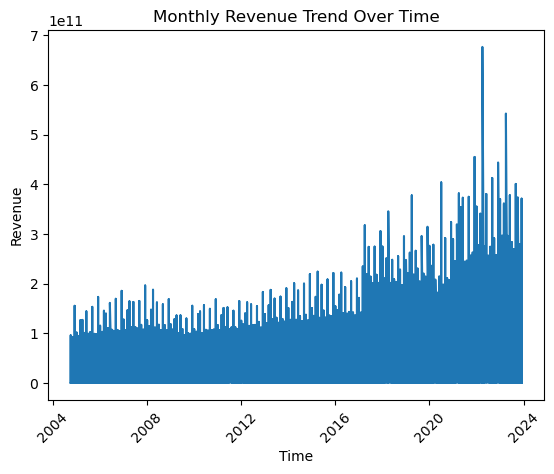

In [ ]:
#Build a monthly revenue trend over time 
plt.figure()
plt.plot(df_monthly["YearMonth"], df_monthly["Net Collections Amount"])
plt.title("Monthly Revenue Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Select predictor variables(X)
X = df_monthly[[
    "Year",
    "Month_sin",
    "Month_cos",
    "Electronic Category Description",
    "Channel Type Description",
    "Tax Category Description"
]]
#Select predictor variables(y)
y = df_monthly["Net Collections Amount"]


In [64]:
split_point = int(len(df_monthly) * 0.8)

X_train = X.iloc[:split_point]
X_test  = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test  = y.iloc[split_point:]


In [ ]:
#Define categorical and numeric features 
categorical_features = [
    "Electronic Category Description",
    "Channel Type Description",
    "Tax Category Description"
]

numeric_features = [
    "Year",
    "Month_sin",
    "Month_cos"
]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
# Create preprocessing pipeline:
# OneHotEncode categorical variables
# Pass numeric variables through unchanged
# drop="first" avoids perfect multicollinearity
# handle_unknown="ignore" ensures model works on unseen categories

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ],
    remainder="drop"
)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
# Apply preprocessing 
#Fit Random Forest Regressor 
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])


In [ ]:
rf_model.fit(X_train, y_train) #ensure that no data leakage from test 


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Electronic Category '
                                                   'Description',
                                                   'Channel Type Description',
                                                   'Tax Category Description']),
                                                 ('num', 'passthrough',
                                                  ['Year', 'Month_sin',
                                                   'Month_cos'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

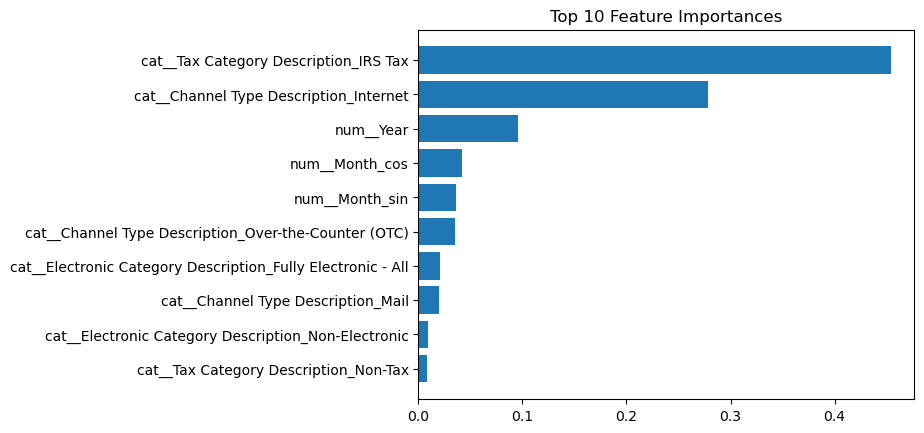

In [ ]:
import numpy as np

feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

indices = np.argsort(importances)[-10:]
#plot the top 10 features importances 
plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Top 10 Feature Importances")
plt.show()


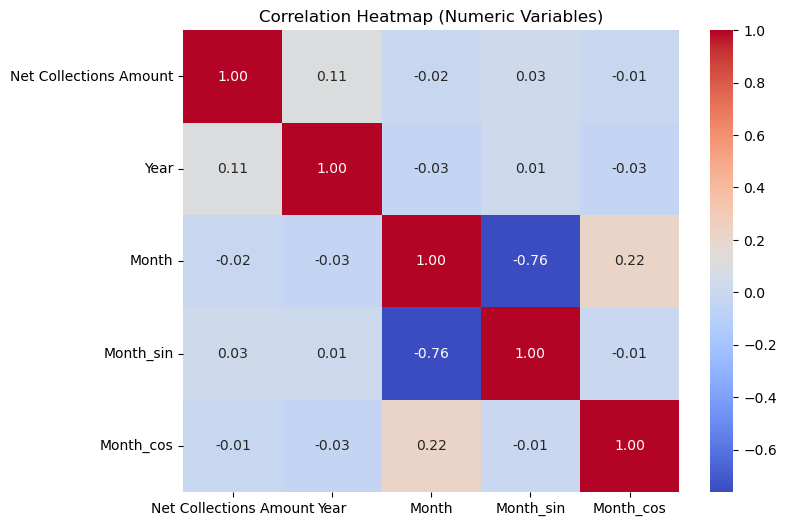

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns only
numeric_df = df_monthly[[
    "Net Collections Amount",
    "Year",
    "Month",
    "Month_sin",
    "Month_cos"
]]

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Variables)")
plt.show()
